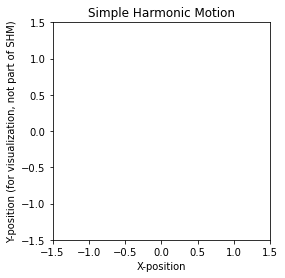

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Define parameters for the Simple Harmonic Motion
amplitude = 1.0  # Amplitude of the oscillation
frequency = 1.0  # Frequency in Hz
phase = 0.0      # Phase in radians

# Create the figure and axes for the plot
fig, ax = plt.subplots()
ax.set_xlim(-1.5 * amplitude, 1.5 * amplitude)
ax.set_ylim(-1.5 * amplitude, 1.5 * amplitude)
ax.set_aspect('equal', adjustable='box')
ax.set_title("Simple Harmonic Motion")
ax.set_xlabel("X-position")
ax.set_ylabel("Y-position (for visualization, not part of SHM)") # Y-axis for visualization

# Initialize the 'ball' object (a circle)
ball, = ax.plot([], [], 'o', markersize=15, color='blue')
# Initialize a line to show the path for context
line, = ax.plot([], [], '-', color='gray', alpha=0.5)

# Time points for the animation
time_points = np.linspace(0, 2 * np.pi / (2 * np.pi * frequency), 200) # One full cycle

# Function to initialize the animation
def init():
    ball.set_data([], [])
    line.set_data([], [])
    return ball, line,

# Function to update the animation for each frame
def animate(i):
    t = time_points[i]
    x = amplitude * np.cos(2 * np.pi * frequency * t + phase)
    y = 0  # Simple harmonic motion in one dimension, so y is constant for the 'ball'

    ball.set_data(x, y)

    # Update the path line to show the motion over time
    current_x_path = amplitude * np.cos(2 * np.pi * frequency * time_points[:i+1] + phase)
    current_y_path = np.zeros_like(current_x_path)
    line.set_data(current_x_path, current_y_path)
    
    return ball, line,

# Create the animation
ani = animation.FuncAnimation(fig, animate, frames=len(time_points), 
                              init_func=init, blit=True, interval=20)

# Display the animation
plt.show()

# Optional: Save the animation as a GIF or MP4
# ani.save('shm_animation.gif', writer='pillow', fps=30) 
# ani.save('shm_animation.mp4', writer='ffmpeg', fps=30)